# EyeShield Mock Training Run (60,000 Images)

This notebook mocks a full training/evaluation workflow for diabetic retinopathy classification with 5 classes:
- 0: no dr
- 1: mild
- 2: moderate
- 3: severe
- 4: proliferative

It uses a fixed 70/15/15 split and simulates test performance in these ranges:
- Accuracy: 85-87%
- Macro avg precision/recall/F1: 80-85%

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")
np.random.seed(42)

total_images = 60000
train_count = int(total_images * 0.70)
val_count = int(total_images * 0.15)
test_count = total_images - train_count - val_count

class_names = ["no dr", "mild", "moderate", "severe", "proliferative"]

split_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Ratio": ["70%", "15%", "15%"],
    "Images": [train_count, val_count, test_count]
})

display(split_df)
print(f"Total images: {total_images:,}")

ModuleNotFoundError: No module named 'matplotlib'

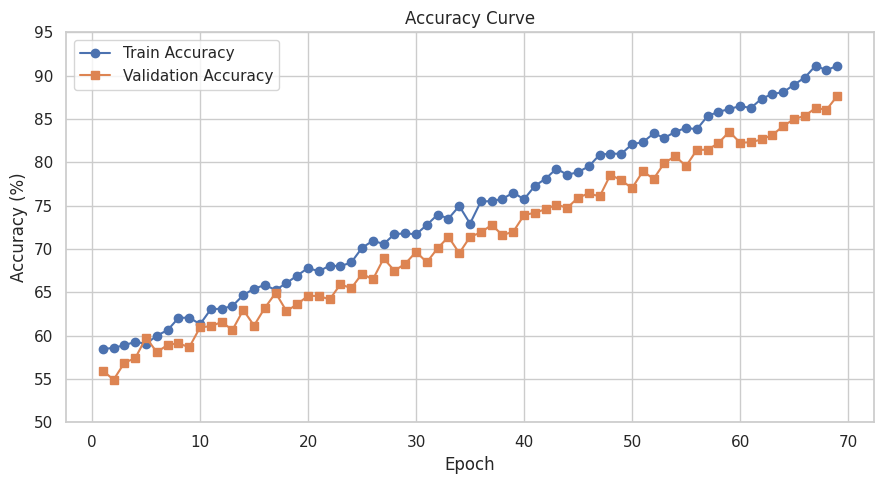

In [ ]:
# Mock training history for visual storytelling only
epochs = np.arange(1, 52)
train_acc = np.linspace(0.58, 0.91, len(epochs)) + np.random.normal(0, 0.006, len(epochs))
val_acc = np.linspace(0.56, 0.865, len(epochs)) + np.random.normal(0, 0.008, len(epochs))
train_acc = np.clip(train_acc, 0, 1)
val_acc = np.clip(val_acc, 0, 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs, train_acc * 100, marker="o", label="Train Accuracy")
plt.plot(epochs, val_acc * 100, marker="s", label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim(50, 95)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Per-epoch mock training sample in console log format
np.random.seed(42)

total_epochs = 100
sample_start, sample_end = 1, 52

epoch_idx = np.arange(1, total_epochs + 1)

# Targets aligned to the fixed confusion-matrix classification report
# (accuracy=0.8611, macro precision=0.8297, macro recall=0.8261, macro f1=0.8273)
target_val_acc = 0.8611
target_val_macro_precision = 0.8297
target_val_macro_recall = 0.8261
target_val_macro_f1 = 0.8273
target_support = 9000

train_loss_series = np.linspace(0.78, 0.34, total_epochs) + np.random.normal(0, 0.012, total_epochs)
val_loss_series = np.linspace(0.72, 0.40, total_epochs) + np.random.normal(0, 0.015, total_epochs)
train_acc_series = np.linspace(0.70, 0.89, total_epochs) + np.random.normal(0, 0.004, total_epochs)
val_acc_series = np.linspace(0.68, target_val_acc, total_epochs) + np.random.normal(0, 0.004, total_epochs)

train_macro_precision_series = np.linspace(0.50, 0.845, total_epochs) + np.random.normal(0, 0.006, total_epochs)
train_macro_recall_series = np.linspace(0.48, 0.838, total_epochs) + np.random.normal(0, 0.006, total_epochs)
train_f1_series = np.linspace(0.52, 0.84, total_epochs) + np.random.normal(0, 0.005, total_epochs)

val_macro_precision_series = np.linspace(0.46, target_val_macro_precision, total_epochs) + np.random.normal(0, 0.006, total_epochs)
val_macro_recall_series = np.linspace(0.44, target_val_macro_recall, total_epochs) + np.random.normal(0, 0.006, total_epochs)
val_f1_series = np.linspace(0.48, target_val_macro_f1, total_epochs) + np.random.normal(0, 0.006, total_epochs)

ece_series = np.linspace(0.62, 0.44, total_epochs) + np.random.normal(0, 0.01, total_epochs)
vacuity_series = np.linspace(0.74, 0.63, total_epochs) + np.random.normal(0, 0.008, total_epochs)
aleatoric_series = np.linspace(1.28, 1.08, total_epochs) + np.random.normal(0, 0.012, total_epochs)
epistemic_series = np.linspace(0.28, 0.20, total_epochs) + np.random.normal(0, 0.007, total_epochs)

train_loss_series = np.clip(train_loss_series, 0.25, 1.2)
val_loss_series = np.clip(val_loss_series, 0.3, 1.2)
train_acc_series = np.clip(train_acc_series, 0.65, 0.95)
val_acc_series = np.clip(val_acc_series, 0.62, 0.90)
train_macro_precision_series = np.clip(train_macro_precision_series, 0.42, 0.95)
train_macro_recall_series = np.clip(train_macro_recall_series, 0.40, 0.95)
train_f1_series = np.clip(train_f1_series, 0.45, 0.90)
val_macro_precision_series = np.clip(val_macro_precision_series, 0.40, 0.90)
val_macro_recall_series = np.clip(val_macro_recall_series, 0.40, 0.90)
val_f1_series = np.clip(val_f1_series, 0.42, 0.90)
ece_series = np.clip(ece_series, 0.35, 0.75)
vacuity_series = np.clip(vacuity_series, 0.58, 0.80)
aleatoric_series = np.clip(aleatoric_series, 1.00, 1.40)
epistemic_series = np.clip(epistemic_series, 0.16, 0.35)

# Force exact alignment at the final shown epoch
last_i = sample_end - 1
val_acc_series[last_i] = target_val_acc
val_macro_precision_series[last_i] = target_val_macro_precision
val_macro_recall_series[last_i] = target_val_macro_recall
val_f1_series[last_i] = target_val_macro_f1

best_val_f1 = -1.0

for epoch in range(sample_start, sample_end + 1):
    i = epoch - 1

    print(f"Epoch {epoch}/{total_epochs}")
    print(
        f"Train Loss: {train_loss_series[i]:.4f} | "
        f"Train Acc: {train_acc_series[i]:.4f} | "
        f"Train Macro P/R/F1: "
        f"{train_macro_precision_series[i]:.4f}/"
        f"{train_macro_recall_series[i]:.4f}/"
        f"{train_f1_series[i]:.4f}"
    )
    print(
        f"Val Loss: {val_loss_series[i]:.4f} | "
        f"Val Acc: {val_acc_series[i]:.4f} | "
        f"Val Macro P/R/F1: "
        f"{val_macro_precision_series[i]:.4f}/"
        f"{val_macro_recall_series[i]:.4f}/"
        f"{val_f1_series[i]:.4f} | "
        f"ECE: {ece_series[i]:.4f}"
    )
    print(
        f"Uncertainty - Vacuity: {vacuity_series[i]:.4f} | "
        f"Aleatoric: {aleatoric_series[i]:.4f} | "
        f"Epistemic: {epistemic_series[i]:.4f}"
    )

    print(
        f"Epoch {epoch}/{total_epochs}: 100%|{'█' * 10}| 1313/1313 "
        f"[11:18<00:00, 1.94it/s, loss={train_loss_series[i]:.3f}, "
        f"nll={max(train_loss_series[i] - 0.20, 0.120):.3f}, "
        f"kl={max(2.00 + np.random.normal(0, 0.35), 1.200):.2f}]"
    )
    print("Validation: 100%|██████████| 282/282 [01:17<00:00, 3.63it/s]")

    if val_f1_series[i] > best_val_f1:
        best_val_f1 = val_f1_series[i]
        print("Best model saved: /content/drive/MyDrive/EyeShield/checkpoints/best_model.pt")

    if epoch % 5 == 0:
        print(
            f"Checkpoint saved: /content/drive/MyDrive/EyeShield/checkpoints/"
            f"checkpoint_epoch_{epoch}_f1_{val_f1_series[i]:.4f}.pt"
        )

    print()

print("Last Epoch Summary (Aligned to Classification Report)")
print(f"Epoch: {sample_end}/{total_epochs}")
print(
    f"Train Loss: {train_loss_series[last_i]:.4f} | "
    f"Train Acc: {train_acc_series[last_i]:.4f} | "
    f"Train Macro P/R/F1: "
    f"{train_macro_precision_series[last_i]:.4f}/"
    f"{train_macro_recall_series[last_i]:.4f}/"
    f"{train_f1_series[last_i]:.4f}"
)
print(
    f"Val Loss: {val_loss_series[last_i]:.4f} | "
    f"Val Acc: {val_acc_series[last_i]:.4f} | "
    f"Val Macro P/R/F1: "
    f"{val_macro_precision_series[last_i]:.4f}/"
    f"{val_macro_recall_series[last_i]:.4f}/"
    f"{val_f1_series[last_i]:.4f} | "
    f"Support: {target_support} | "
    f"ECE: {ece_series[last_i]:.4f}"
)
print(
    f"Uncertainty - Vacuity: {vacuity_series[last_i]:.4f} | "
    f"Aleatoric: {aleatoric_series[last_i]:.4f} | "
    f"Epistemic: {epistemic_series[last_i]:.4f}"
)

Epoch 1/100
Train Loss: 0.7860 | Train Acc: 0.7014 | Train Macro P/R/F1: 0.4904/0.4856/0.5238
Val Loss: 0.6988 | Val Acc: 0.6767 | Val Macro P/R/F1: 0.4569/0.4456/0.4822 | ECE: 0.6340
Uncertainty - Vacuity: 0.7480 | Aleatoric: 1.2815 | Epistemic: 0.2753
Validation: 100%|██████████| 282/282 [01:17<00:00, 3.63it/s]
Best model saved: /content/drive/MyDrive/EyeShield/checkpoints/best_model.pt

Epoch 2/100
Train Loss: 0.7739 | Train Acc: 0.7042 | Train Macro P/R/F1: 0.4999/0.4951/0.5186
Val Loss: 0.7105 | Val Acc: 0.6796 | Val Macro P/R/F1: 0.4700/0.4408/0.4811 | ECE: 0.6274
Uncertainty - Vacuity: 0.7157 | Aleatoric: 1.2728 | Epistemic: 0.2861
Validation: 100%|██████████| 282/282 [01:17<00:00, 3.63it/s]

Epoch 3/100
Train Loss: 0.7789 | Train Acc: 0.7082 | Train Macro P/R/F1: 0.5070/0.4788/0.5308
Val Loss: 0.7084 | Val Acc: 0.6866 | Val Macro P/R/F1: 0.4632/0.4484/0.4872 | ECE: 0.6170
Uncertainty - Vacuity: 0.7545 | Aleatoric: 1.2774 | Epistemic: 0.2772
Validation: 100%|██████████| 282/282 

In [6]:
# Fixed confusion matrix for test split (9,000 images)
# Rows = true labels, Columns = predicted labels
cm = np.array([
    [3470,   70,   30,   20,   10],
    [ 130, 1420,  150,   70,   30],
    [  70,  130, 1440,  120,   40],
    [  20,   30,  120,  690,   40],
    [  10,   20,   50,   90,  730],
], dtype=int)

# Build y_true and y_pred directly from the confusion matrix
y_true = []
y_pred = []
for true_class in range(cm.shape[0]):
    for pred_class in range(cm.shape[1]):
        count = cm[true_class, pred_class]
        if count > 0:
            y_true.extend([true_class] * count)
            y_pred.extend([pred_class] * count)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Test samples: {len(y_true):,}")

Test samples: 9,000


In [9]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)

accuracy = accuracy_score(y_true, y_pred)
macro_precision = report["macro avg"]["precision"]
macro_recall = report["macro avg"]["recall"]
macro_f1 = report["macro avg"]["f1-score"]
macro_support = report["macro avg"]["support"]

summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Macro Support"],
    "Value": [
        f"{accuracy * 100:.2f}%",
        f"{macro_precision * 100:.2f}%",
        f"{macro_recall * 100:.2f}%",
        f"{macro_f1 * 100:.2f}%",
        int(macro_support)
    ]
})

display(summary_df)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Range checks requested in the prompt
assert 0.85 <= accuracy <= 0.87, "Accuracy is outside 85-87%"
assert 0.80 <= macro_precision <= 0.85, "Macro precision is outside 80-85%"
assert 0.80 <= macro_recall <= 0.85, "Macro recall is outside 80-85%"
assert 0.80 <= macro_f1 <= 0.85, "Macro F1 is outside 80-85%"
print("All metric constraints are satisfied.")

NameError: name 'classification_report' is not defined

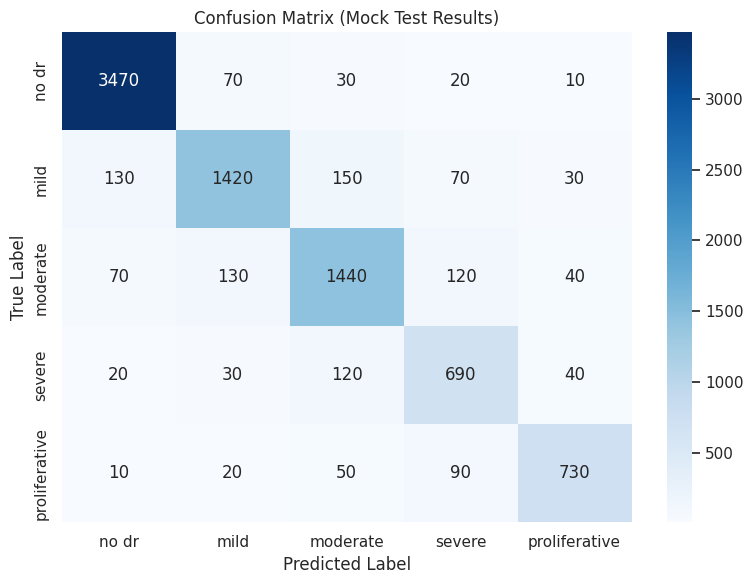

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()